# Exploratory Data Analysis — Credit Card Default

Dataset: **UCI id=350, "Default of Credit Card Clients"** (Taiwan, 2005).
30,000 clients, 23 features, binary target.

This notebook answers the questions that determine *how* the six models get built:

1. How imbalanced is the target, and what does a do-nothing model score?
2. Do the features share a scale? (decides whether scaling is optional or mandatory)
3. What do the undocumented `PAY_*` codes mean, and is their ordering real?
4. Which features actually carry signal?
5. Is there collinearity that will affect how we read Logistic Regression?

Run `python -m model.data_prep` first to generate `data/train.csv`.

**Analysis uses the training split only.** Looking at the test set to make
modelling decisions is a subtle form of leakage: choices get tuned to data that is
supposed to be unseen, and the reported metrics stop being an honest estimate.

In [1]:
import sys
from pathlib import Path

# Work whether the notebook runs from the repo root or from model/.
ROOT = Path.cwd() if (Path.cwd() / 'model').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from model import config, viz

viz.apply_style()

FIGDIR = ROOT / 'reports' / 'figures'
FIGDIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(config.TRAIN_CSV)
y = train[config.TARGET]

print('train shape :', train.shape)
print('features    :', len(config.FEATURES), '(assignment minimum is 12)')
print('instances   :', len(train), '(assignment minimum is 500)')
print('nulls       :', int(train.isna().sum().sum()))

train shape : (23972, 24)
features    : 23 (assignment minimum is 12)
instances   : 23972 (assignment minimum is 500)
nulls       : 0


## 1. Class balance, and the number every model must beat

The target is **not** balanced. That single fact drives how the results get read.

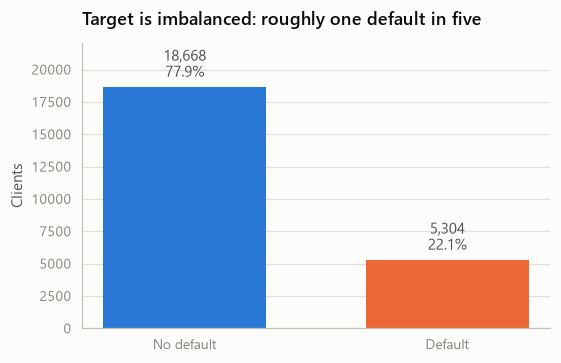

Majority-class (predict "no default" always) baseline:
  Accuracy  77.8742%   <-- looks excellent, model is useless
  Precision 0.0    (never predicts the positive class)
  Recall    0.0    (catches zero defaulters)
  F1        0.0
  MCC       0.0    (no correlation with truth)
  AUC       0.5    (no better than a coin flip)


In [2]:
counts = y.value_counts().sort_index()
rates = y.value_counts(normalize=True).sort_index()

fig, ax = plt.subplots(figsize=(5.2, 3.4))
labels = [viz.CLASS_LABELS[k] for k in counts.index]
colors = [viz.CLASS_COLORS[k] for k in counts.index]
bars = ax.bar(labels, counts.values, color=colors, width=0.62)

# Direct labels: with two bars a legend would be redundant chrome.
for bar, n, r in zip(bars, counts.values, rates.values):
    ax.annotate(f'{n:,}\n{r:.1%}',
                (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                ha='center', va='bottom', fontsize=9.5,
                color=viz.INK_SECONDARY, xytext=(0, 4),
                textcoords='offset points')

ax.set_title('Target is imbalanced: roughly one default in five')
ax.set_ylabel('Clients')
ax.set_ylim(0, counts.max() * 1.18)
viz.grid_axis(ax, 'y')
fig.tight_layout()
fig.savefig(FIGDIR / 'class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

majority = 1 - y.mean()
print(f'Majority-class (predict "no default" always) baseline:')
print(f'  Accuracy  {majority:.4%}   <-- looks excellent, model is useless')
print(f'  Precision 0.0    (never predicts the positive class)')
print(f'  Recall    0.0    (catches zero defaulters)')
print(f'  F1        0.0')
print(f'  MCC       0.0    (no correlation with truth)')
print(f'  AUC       0.5    (no better than a coin flip)')

**This is the most important cell in the notebook.**

A model that always predicts "no default" scores about **77.9% accuracy**. So
accuracy in the high-70s means *nothing has been learned*. Meanwhile that same
model scores 0.0 on recall, F1 and MCC, and 0.5 on AUC.

This is why the comparison table needs all six metrics, and why **MCC and AUC**
should be treated as the headline numbers:

- **MCC** uses all four confusion-matrix cells, so it cannot be inflated by
  getting the easy majority class right. F1 ignores true negatives entirely.
- **AUC** is threshold-independent, so it measures how well a model *ranks* risk
  rather than how well the fixed 0.5 cutoff happens to suit a 22% base rate.

## 2. Feature scales differ by ~5 orders of magnitude

This decides whether feature scaling is a nicety or a requirement.

,min,max,mean,std,range
LIMIT_BAL,"10,000","1,000,000","167,273","129,870","990,000"
AGE,21,75,35,9,54
BILL_AMT1,"-165,580","964,511","51,271","73,242","1,130,091"
BILL_AMT2,"-69,777","983,931","49,292","70,980","1,053,708"
BILL_AMT3,"-157,264","1,664,089","47,096","69,410","1,821,353"
BILL_AMT4,"-81,334","891,586","43,379","64,356","972,920"
BILL_AMT5,"-61,372","927,171","40,382","60,718","988,543"
BILL_AMT6,"-339,603","961,664","38,899","59,577","1,301,267"
PAY_AMT1,0,"873,552","5,652","16,681","873,552"
PAY_AMT2,0,"1,684,259","5,934","24,152","1,684,259"


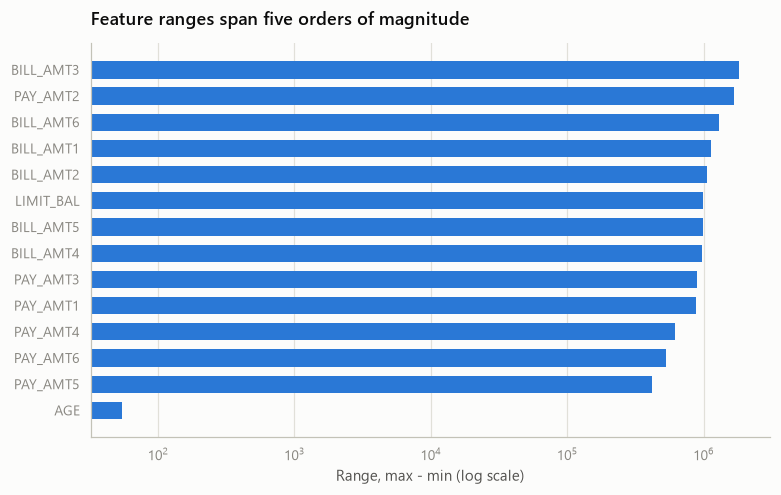

Largest range / smallest range = 33,729x


In [3]:
scale = train[config.NUMERIC].agg(['min', 'max', 'mean', 'std']).T
scale['range'] = scale['max'] - scale['min']
display(scale.style.format('{:,.0f}').set_caption('Numeric feature scales'))

fig, ax = plt.subplots(figsize=(7.2, 4.6))
order = scale['range'].sort_values()
ax.barh(order.index, order.values, color=viz.SERIES[0], height=0.66)
ax.set_xscale('log')
ax.set_title('Feature ranges span five orders of magnitude')
ax.set_xlabel('Range, max - min (log scale)')
viz.grid_axis(ax, 'x')
fig.tight_layout()
fig.savefig(FIGDIR / 'feature_scales.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = order.max() / order.min()
print(f'Largest range / smallest range = {ratio:,.0f}x')

`AGE` spans 58 years. `LIMIT_BAL` spans about a million NT dollars.

**Consequence for kNN.** Euclidean distance sums squared differences across
features. Unscaled, a 100,000-dollar credit-limit gap contributes ~10^10 to the
distance while a 40-year age gap contributes ~10^3. kNN would effectively be
a one-feature model using only `LIMIT_BAL`. Scaling is **mandatory**.

**Consequence for Logistic Regression.** The optimiser has to take tiny steps to
avoid diverging on the large-magnitude features, so it converges slowly or hits
the iteration cap. Scaling is effectively required.

**Not an issue for trees, Random Forest or Gradient Boosting.** They split on
thresholds within a single feature at a time, so any monotonic rescaling produces
identical splits. We scale everything anyway, purely so all six pipelines are
structurally identical — it changes the tree models' results not at all.

## 3. The `PAY_*` columns and their undocumented codes

UCI documents `-1` = paid duly and `1..9` = months of delay. The data also
contains **`-2` and `0`** — and `0` is the most common value in every month.

,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
-2,2167,2968,3217,3432,3605,3893
-1,4528,4828,4725,4560,4429,4608
0,11820,12624,12671,13188,13573,13027
1,2949,22,3,2,0,0
2,2143,3139,3052,2507,2098,2211
3,250,264,185,152,147,136
4,62,78,65,56,61,35
5,20,23,17,26,11,10
6,10,10,18,3,3,16
7,8,16,16,44,44,35


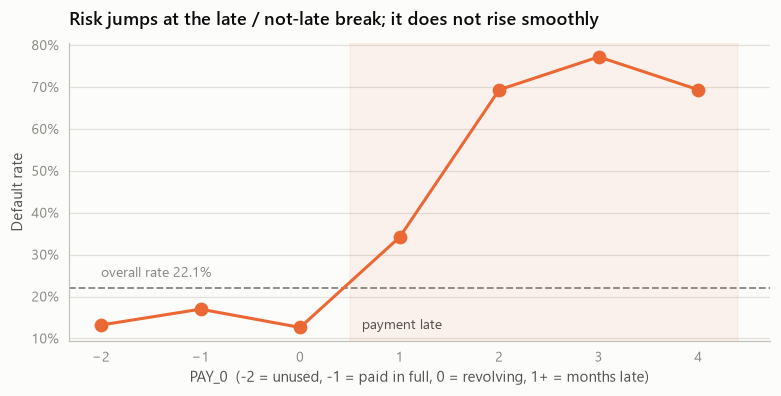

Default rate by PAY_0 code (groups with >= 25 clients):
   -2 : 13.2%   (n=2,167)
   -1 : 17.0%   (n=4,528)
    0 : 12.6%   (n=11,820)
    1 : 34.2%   (n=2,949)
    2 : 69.3%   (n=2,143)
    3 : 77.2%   (n=250)
    4 : 69.4%   (n=62)

Monotonically increasing across every code? False

Grouped at the threshold:
  PAY_0 <= 0  (not late) : 13.8%   (n=18,515)
  PAY_0 >= 1  (late)     : 50.5%   (n=5,457)
  risk ratio             : 3.7x


In [4]:
codes = pd.DataFrame({c: train[c].value_counts() for c in config.ORDINAL})
codes = codes.sort_index().fillna(0).astype(int)
display(codes.style.set_caption('PAY_* code frequency by month'))

# Does the code ordering actually track risk? Plot default rate per code.
rate_by_code = train.groupby('PAY_0')[config.TARGET].agg(['mean', 'size'])
rate_by_code = rate_by_code[rate_by_code['size'] >= 25]

fig, ax = plt.subplots(figsize=(7.2, 3.7))
# Shade the late-payment region: the structural break sits between 0 and 1.
ax.axvspan(0.5, rate_by_code.index.max() + 0.4,
           color=viz.SERIES[1], alpha=0.07, zorder=1)
ax.plot(rate_by_code.index, rate_by_code['mean'],
        marker='o', color=viz.SERIES[1], zorder=3)
ax.axhline(y.mean(), color=viz.INK_MUTED, linestyle='--', linewidth=1.2, zorder=2)
ax.annotate(f'overall rate {y.mean():.1%}',
            (rate_by_code.index.min(), y.mean()),
            xytext=(0, 7), textcoords='offset points',
            fontsize=9, color=viz.INK_MUTED)
# x in data coords, y as an axes fraction, so the label cannot fall off the
# bottom when matplotlib picks a non-zero y-axis floor.
ax.text(0.62, 0.04, 'payment late', fontsize=9, color=viz.INK_SECONDARY,
        transform=ax.get_xaxis_transform())
ax.set_title('Risk jumps at the late / not-late break; it does not rise smoothly')
ax.set_xlabel('PAY_0  (-2 = unused, -1 = paid in full, 0 = revolving, 1+ = months late)')
ax.set_ylabel('Default rate')
ax.yaxis.set_major_formatter(lambda v, _: f'{v:.0%}')
ax.set_xticks(rate_by_code.index)
viz.grid_axis(ax, 'y')
fig.tight_layout()
fig.savefig(FIGDIR / 'pay0_default_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print('Default rate by PAY_0 code (groups with >= 25 clients):')
for code, row in rate_by_code.iterrows():
    pct = row['mean']
    n = int(row['size'])
    print(f'  {int(code):>3} : {pct:.1%}   (n={n:,})')

is_mono = rate_by_code['mean'].is_monotonic_increasing
print()
print(f'Monotonically increasing across every code? {is_mono}')

not_late = train.loc[train['PAY_0'] <= 0, config.TARGET]
late = train.loc[train['PAY_0'] >= 1, config.TARGET]
print()
print('Grouped at the threshold:')
print(f'  PAY_0 <= 0  (not late) : {not_late.mean():.1%}   (n={len(not_late):,})')
print(f'  PAY_0 >= 1  (late)     : {late.mean():.1%}   (n={len(late):,})')
print(f'  risk ratio             : {late.mean() / not_late.mean():.1f}x')

The relationship is **not monotonic** — and that is more informative than if it were.

Three codes sit *below* the overall 22% rate and are not cleanly ordered among
themselves: `-2` (no credit used) at 13.2%, `-1` (paid in full) at 17.0%, and `0`
(revolving a balance) at 12.6%. A client quietly revolving a balance is, in this
data, no riskier than one who paid in full. The top end wobbles too — code `4`
comes in slightly below code `3`, where the sample sizes are small.

The real structure is a **threshold**. The moment `PAY_0` reaches 1, the rate
jumps to 34%, then 69%, then 77%. Grouped at that break, "not late" runs
13.8% against "late" at 50.5% — a risk ratio of 3.7x. That single break
carries most of the column's predictive power.

**So why keep `PAY_*` ordinal instead of one-hot encoding it?**

- The dominant signal is one threshold, and a single ordinal column lets a tree
  capture it in **one split** (`PAY_0 <= 0`). One-hot would need several splits to
  express the same boundary.
- One-hot across all six `PAY_*` columns adds roughly 66 columns, which would hurt
  kNN through the curse of dimensionality for no corresponding gain.
- The non-monotonic region is confined to a narrow 12.6–17.0% band, so treating the
  codes as ordered costs very little in practice.

**The caveat this exposes for Logistic Regression.** It fits one coefficient per
feature, so it can only say "risk rises with the code" — a straight line through
what is really a step function. It cannot represent the `-2 / -1 / 0` inversion at
all. Expect it to trail the tree-based models here, and note that we now have a
*mechanism* for that prediction rather than just an observation. M4 tests it.

## 4. How the two classes differ

Two series now, so each chart carries a legend — identity is never colour-alone.

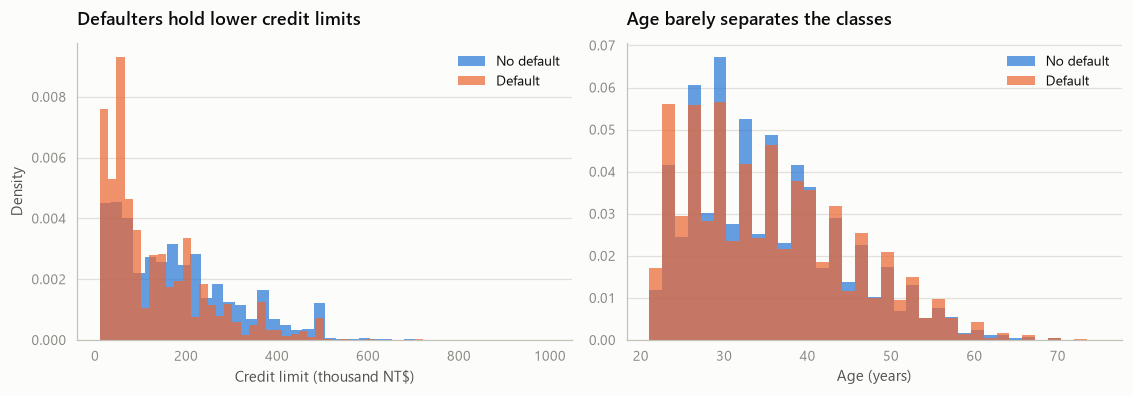

Median credit limit:
  No default     150,000 NT$
  Default         90,000 NT$

Mean age:
  No default        35.4 years
  Default           35.6 years


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10.4, 3.7))

for cls in (0, 1):
    subset = train[y == cls]
    axes[0].hist(subset['LIMIT_BAL'] / 1000, bins=40, alpha=0.72,
                 color=viz.CLASS_COLORS[cls], label=viz.CLASS_LABELS[cls],
                 density=True)
    axes[1].hist(subset['AGE'], bins=35, alpha=0.72,
                 color=viz.CLASS_COLORS[cls], label=viz.CLASS_LABELS[cls],
                 density=True)

axes[0].set_title('Defaulters hold lower credit limits')
axes[0].set_xlabel('Credit limit (thousand NT$)')
axes[0].set_ylabel('Density')
axes[1].set_title('Age barely separates the classes')
axes[1].set_xlabel('Age (years)')

for ax in axes:
    ax.legend(loc='upper right')
    viz.grid_axis(ax, 'y')

fig.tight_layout()
fig.savefig(FIGDIR / 'class_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Median credit limit:')
for cls in (0, 1):
    med = train.loc[y == cls, 'LIMIT_BAL'].median()
    print(f'  {viz.CLASS_LABELS[cls]:<11} {med:>10,.0f} NT$')
print('\nMean age:')
for cls in (0, 1):
    print(f'  {viz.CLASS_LABELS[cls]:<11} {train.loc[y == cls, "AGE"].mean():>10.1f} years')

## 5. Which features carry signal?

Correlation with the target can be positive or negative, so this is a **polarity**
encoding: a diverging blue/red scale around a neutral midpoint, where colour
reinforces the sign the axis already shows.

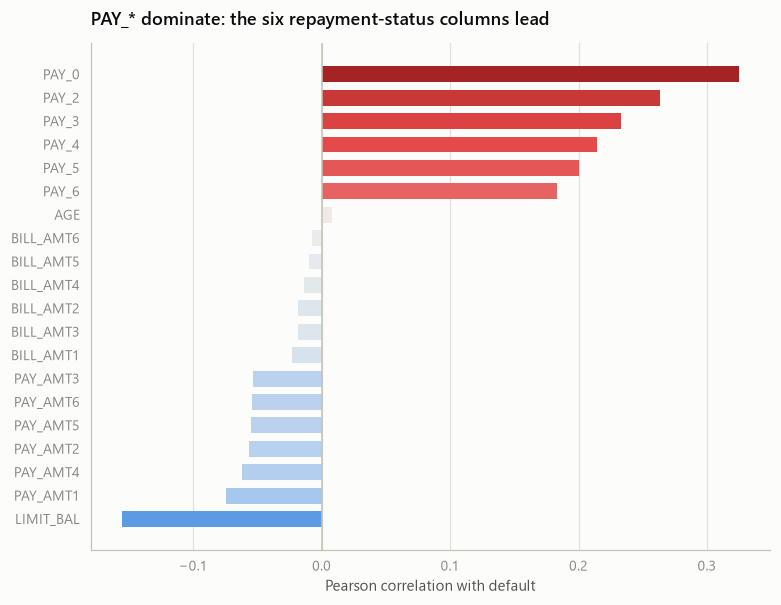

Top 8 by absolute correlation:
  PAY_0        +0.3250
  PAY_2        +0.2637
  PAY_3        +0.2331
  PAY_4        +0.2141
  PAY_5        +0.2006
  PAY_6        +0.1832
  LIMIT_BAL    -0.1557
  PAY_AMT1     -0.0741


In [6]:
corr = train[config.NUMERIC + config.ORDINAL].corrwith(y).sort_values()

fig, ax = plt.subplots(figsize=(7.2, 5.6))
vmax = np.abs(corr).max()
norm = plt.Normalize(-vmax, vmax)
ax.barh(corr.index, corr.values,
        color=[viz.CMAP_DIV(norm(v)) for v in corr.values], height=0.68)
ax.axvline(0, color=viz.BASELINE, linewidth=1.0)
ax.set_title('PAY_* dominate: the six repayment-status columns lead')
ax.set_xlabel('Pearson correlation with default')
viz.grid_axis(ax, 'x')
fig.tight_layout()
fig.savefig(FIGDIR / 'target_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 8 by absolute correlation:')
for name, val in corr.reindex(corr.abs().sort_values(ascending=False).index).head(8).items():
    print(f'  {name:<12} {val:+.4f}')

All six `PAY_*` columns outrank every other feature, with `PAY_0` (the most
recent month) strongest at about **+0.32**. Recent repayment behaviour is the
dominant signal — which is intuitive, and means we should expect the tree-based
models to split on `PAY_0` at the root.

`LIMIT_BAL` correlates **negatively** (about −0.15): higher limits are granted to
lower-risk clients, so the causality runs from creditworthiness to limit, not the
other way round.

Note these are *linear* correlations. A near-zero value here does not mean a
feature is useless — trees can exploit non-monotonic structure that Pearson
correlation is blind to.

## 6. Collinearity among the bill amounts

The `BILL_AMT*` values are all positive magnitudes here, so this one is a
**sequential** single-hue encoding rather than diverging.

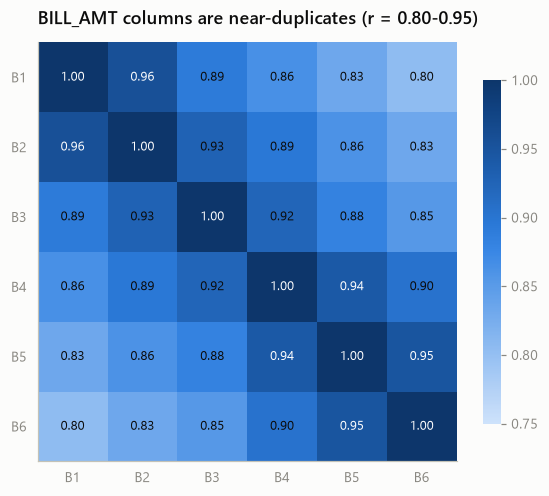

Off-diagonal correlations: min 0.805, max 0.955


In [7]:
bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
bill_corr = train[bill_cols].corr()

fig, ax = plt.subplots(figsize=(5.4, 4.5))
im = ax.imshow(bill_corr.values, cmap=viz.CMAP_SEQ, vmin=0.75, vmax=1.0)
ax.set_xticks(range(len(bill_cols)), [c.replace('BILL_AMT', 'B') for c in bill_cols])
ax.set_yticks(range(len(bill_cols)), [c.replace('BILL_AMT', 'B') for c in bill_cols])
ax.grid(False)

for i in range(len(bill_cols)):
    for j in range(len(bill_cols)):
        v = bill_corr.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8.5,
                color='white' if v > 0.93 else viz.INK_PRIMARY)

ax.set_title('BILL_AMT columns are near-duplicates (r = 0.80-0.95)')
cbar = fig.colorbar(im, ax=ax, shrink=0.82)
cbar.outline.set_visible(False)
fig.tight_layout()
fig.savefig(FIGDIR / 'bill_collinearity.png', dpi=150, bbox_inches='tight')
plt.show()

off_diag = bill_corr.values[~np.eye(len(bill_cols), dtype=bool)]
print(f'Off-diagonal correlations: min {off_diag.min():.3f}, max {off_diag.max():.3f}')

Adjacent months correlate at up to **0.95** — a client's bill barely moves
month to month.

**Why this matters for Logistic Regression specifically.** With six
near-duplicate predictors, the model can distribute weight among them almost
arbitrarily and reach the same fit. Individual coefficients become unstable and
can even flip sign, so *interpreting* them as "the effect of month 3's bill" is
unsound. Predictive accuracy is largely unaffected; interpretability is what
degrades.

**Trees and forests are unbothered** — they simply pick whichever correlated
column splits best. The cost surfaces instead in Random Forest *feature
importances*, which get diluted across the correlated group, making each look
less important than the group collectively is.

## 7. A data-quality wrinkle: contradictory records

`data_prep.py` removed 35 exact duplicate rows. But deduplicating on features
*alone* finds more than that — the difference is rows that are identical in every
feature yet carry **opposite labels**.

In [8]:
feat_dupes = int(train.duplicated(subset=config.FEATURES).sum())
full_dupes = int(train.duplicated().sum())

print(f'Duplicated on features only : {feat_dupes}')
print(f'Duplicated on features+label: {full_dupes}')
print(f'Contradictory (same features, different label): {feat_dupes - full_dupes}')

if feat_dupes:
    grp = train.groupby(config.FEATURES, dropna=False)[config.TARGET]
    conflicting = grp.nunique()
    n_conflict = int((conflicting > 1).sum())
    print(f'\nFeature combinations appearing with both labels: {n_conflict}')
    print('These set an irreducible error floor: no model, however good, can')
    print('classify both copies correctly. The count is tiny, so the effect on')
    print('the metrics is negligible -- but it is why 100% accuracy is impossible.')

Duplicated on features only : 12
Duplicated on features+label: 0
Contradictory (same features, different label): 12

Feature combinations appearing with both labels: 12
These set an irreducible error floor: no model, however good, can
classify both copies correctly. The count is tiny, so the effect on
the metrics is negligible -- but it is why 100% accuracy is impossible.


## What this means for the six models

| Finding | Consequence |
|---|---|
| 22.1% positive; all-negative baseline = 77.9% accuracy | Judge models on **MCC and AUC**, not accuracy. Expect modest recall at the default 0.5 threshold. |
| Feature ranges differ ~10^5 | Scaling **mandatory** for kNN and Logistic Regression; irrelevant to the tree models. |
| `PAY_*` codes are monotonic in risk | Keep them **ordinal**, not one-hot. Avoids ~66 columns that would hurt kNN. |
| `PAY_0` is the strongest single predictor (+0.32) | Expect tree models to split on it at the root; a stump on `PAY_0` is a reasonable sanity check. |
| `BILL_AMT*` collinear at 0.80–0.95 | Don't over-read Logistic Regression coefficients; expect diluted RF feature importances. |
| `EDUCATION`/`MARRIAGE` are nominal with an "others" bucket | One-hot encode; treating them as numeric would invent a false ordering. |
| A few contradictory records | Small irreducible error floor — 100% accuracy is unattainable, which is a healthy expectation. |

Next: **M2** builds the Logistic Regression, Decision Tree and Naive Bayes
pipelines on top of the `build_preprocessor()` contract fixed in
`model/preprocess.py`.